In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np
from plotting_code import apply_style, add_panel_label, create_multi_panel_figure
apply_style("linux")

In [2]:
from sklearn.preprocessing import StandardScaler
from CBFV.composition import generate_features
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [3]:
combined_df = pd.concat([
    pd.read_csv('results/approx_seed_results.csv'),
    pd.read_csv('results/magpie_seed_results.csv'),
    pd.read_csv('results/oliynyk_seed_results.csv'),
], ignore_index=True)

# Compute summary from raw data
summary = combined_df.groupby(['feature_set', 'model']).agg(
    acc_mean=('test_acc', 'mean'),
    acc_std= ('test_acc', 'std'),
    f1_mean= ('test_f1',  'mean'),
    f1_std=  ('test_f1',  'std'),
).round(4)

print(summary)

                   acc_mean  acc_std  f1_mean  f1_std
feature_set model                                    
approx      dumc     0.3026   0.0000   0.1406  0.0000
            etc      0.8531   0.0043   0.8551  0.0046
            lr       0.7105   0.0000   0.7067  0.0000
            lsvc     0.7368   0.0000   0.7348  0.0000
            rfc      0.8522   0.0077   0.8544  0.0075
magpie      dumc     0.3026   0.0000   0.1406  0.0000
            etc      0.8570   0.0075   0.8580  0.0070
            lr       0.6491   0.0000   0.6433  0.0000
            lsvc     0.6711   0.0000   0.6660  0.0000
            rfc      0.8482   0.0047   0.8504  0.0050
oliynyk     dumc     0.3026   0.0000   0.1406  0.0000
            etc      0.8605   0.0085   0.8625  0.0083
            lr       0.6623   0.0000   0.6585  0.0000
            lsvc     0.7061   0.0000   0.7020  0.0000
            rfc      0.8539   0.0083   0.8560  0.0081


In [4]:
feature_order  = ['approx', 'oliynyk', 'magpie']
model_order    = ['etc', 'rfc', 'lsvc', 'lr', 'dumc']

model_labels = {
    'etc': 'Extra Trees',
    'rfc': 'Random Forest',
    'lsvc': 'LSVC',
    'lr':  'Logistic Regression',
    'dumc': 'Dummy Baseline'
}

feature_labels = {
    'approx': 'Approx',
    'magpie': 'MAGPIE',
    'oliynyk': 'Oliynyk',
}

feature_colors = {
    'approx':  '#993bff',
    'magpie':  '#e55c30',
    'oliynyk': '#fbbe23',
}

custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom", ["#fafafa", "#993bff", "#361a54"])

feature_hatches = {
    'approx':  '//',
    'magpie':  '..',
    'oliynyk': 'xx',
}

In [5]:
def plot_bar(ax, summary):
    x = np.arange(len(model_order))
    width = 0.25

    for i, feat in enumerate(feature_order):
        data = summary.xs(feat, level='feature_set').reindex(model_order)

        ax.bar(
            x + (i - 1) * width,
            data['f1_mean'],
            width=width,
            yerr=data['f1_std'],
            color=feature_colors[feat],
            hatch=feature_hatches[feat],
            edgecolor='white',
            linewidth=0.5,
            capsize=4,
            label=feature_labels[feat],
            zorder=2
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [model_labels[m] for m in model_order],
        rotation=20,
        ha='right'   # helps prevent overlap
    )
    ax.set_ylabel('F1 score')
    ax.set_ylim(0, 1.0)

    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

    ax.legend(
        title='Feature set',
        frameon=False,
        loc='upper right',
    )

In [6]:
def plot_heatmap(ax, summary):
    pivot = summary['f1_mean'].unstack('feature_set').reindex(
        index=model_order, columns=feature_order
    )

    pivot.index = [model_labels[m] for m in model_order]

    sns.heatmap(pivot, annot=True, fmt='.3f', vmin=0, vmax=1,
        cmap=custom_cmap, linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Mean F1 score'},
        ax=ax
    )

    ax.set_xlabel('')
    ax.set_ylabel('')

    # Move labels to top
    ax.xaxis.tick_top()
    ax.set_xticklabels(
        [feature_labels[f] for f in feature_order],
    )
    ax.set_yticklabels(pivot.index, rotation=0)

    # Hide tick marks (NOT ticks themselves)
    ax.tick_params(axis='both', which='both', length=0)
    
    cbar = ax.collections[0].colorbar
    cbar.outline.set_visible(True)
    cbar.outline.set_linewidth(1.5)

In [7]:
def make_bar_figure(summary):
    fig, ax = plt.subplots(figsize=(8,6))
    plot_bar(ax, summary)
    plt.tight_layout()
    return fig


def make_heatmap_figure(summary):
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_heatmap(ax, summary)
    plt.tight_layout()
    return fig


def make_combined_figure(summary):
    fig, axes = create_multi_panel_figure(
        nrows=1,
        ncols=2,
        figsize=(18, 6),
        width_ratios=[1.3, 1],
        wspace=0.3
    )

    plot_bar(axes[0], summary)
    plot_heatmap(axes[1], summary)

    add_panel_label(axes[0], '(a)')
    add_panel_label(axes[1], '(b)')

    return fig

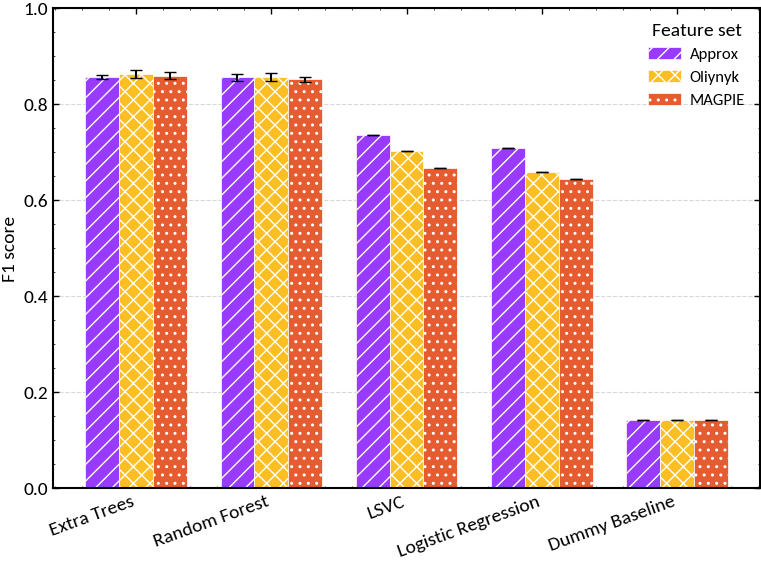

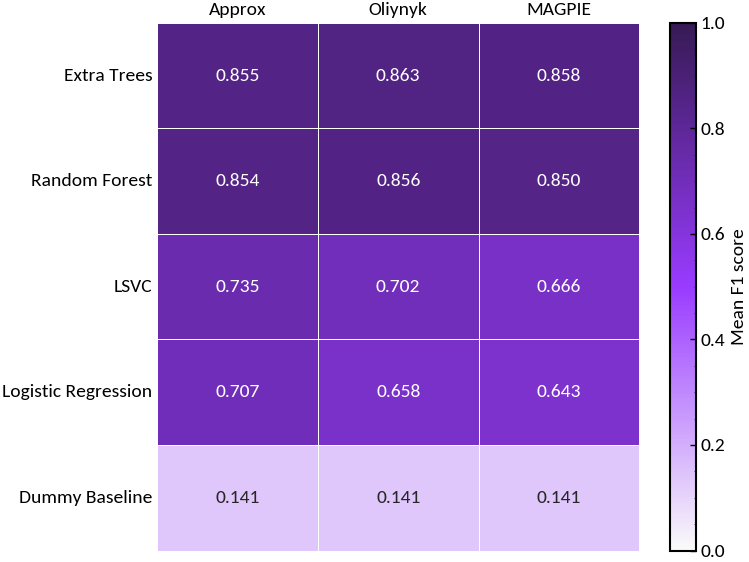

In [8]:
fig = make_bar_figure(summary)
fig.savefig('outputs/model_results_bar.png')
plt.show()

fig = make_heatmap_figure(summary)
fig.savefig('outputs/F1_score_heatmap.png')
plt.show()

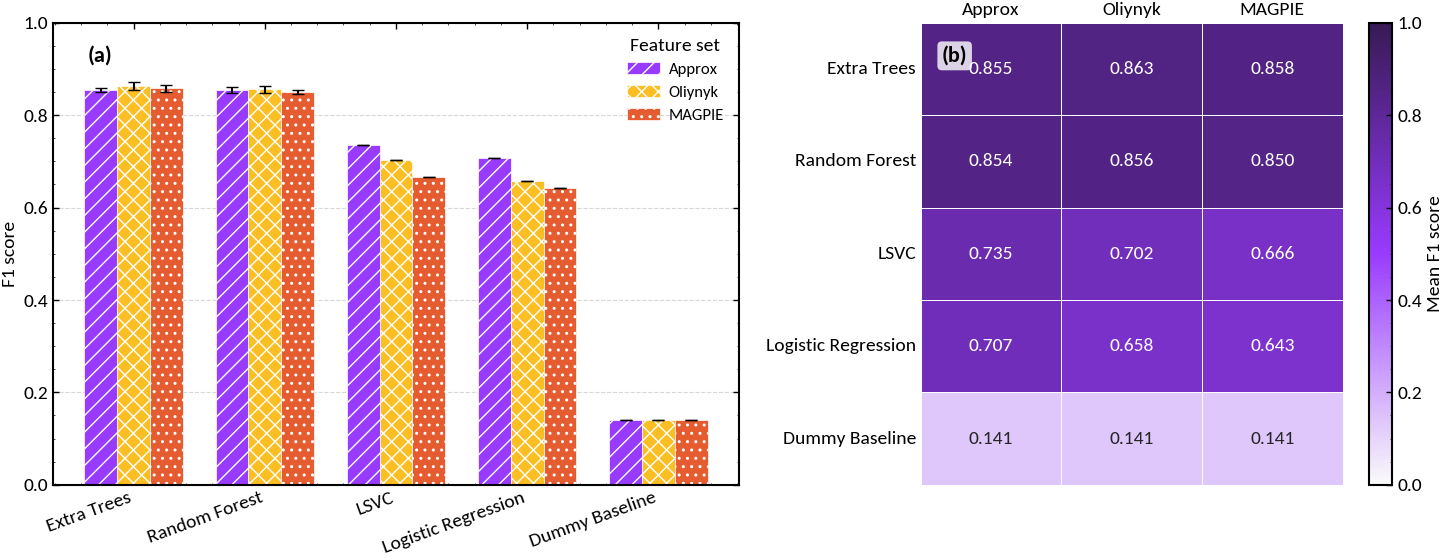

In [9]:
fig = make_combined_figure(summary)
fig.savefig('outputs/model_results.png')
plt.show()

In [10]:
def align_labels(df_train, df_val, df_test, label_col="Crystal_System"):
    for df in (df_train, df_val, df_test):
        df[label_col] = df[label_col].astype("category")

    categories = df_train[label_col].cat.categories

    for df in (df_train, df_val, df_test):
        df[label_col] = df[label_col].cat.set_categories(categories)
        df["target"] = df[label_col].cat.codes

    label_mapping = dict(enumerate(categories))
    return df_train, df_val, df_test, label_mapping

# =================================================================
# 1. ApprOxiMate features
# =================================================================
df_train = pd.read_csv('approx_dataset_splits/app_train_split.csv')
df_test  = pd.read_csv('approx_dataset_splits/app_test_split.csv')
df_val   = pd.read_csv('approx_dataset_splits/app_val_split.csv')

df_train, df_val, df_test, label_mapping_approx = align_labels(df_train, df_val, df_test)

feature_cols_approx = [
    col for col in df_train.columns
    if col not in ['HMS', 'Chemical', 'Crystal_System', 'target', 'formula']
]

X_train_approx = df_train[feature_cols_approx].values
y_train_approx          = df_train['target'].values

X_val_approx = df_val[feature_cols_approx].values
y_val_approx           = df_val['target'].values

X_test_approx = df_test[feature_cols_approx].values
y_test_approx           = df_test['target'].values

# combined full dataset for visualization
X_full_approx = np.concatenate(
    [X_train_approx, X_val_approx, X_test_approx], axis=0
)
y_full_approx = np.concatenate([y_train_approx, y_val_approx, y_test_approx], axis=0)

split_labels_approx = (
    ['train'] * len(y_train_approx) + ['val'] * len(y_val_approx) + ['test'] * len(y_test_approx)
)

# =================================================================
# 2. Magpie features (via CBFV)
# =================================================================
df_train = pd.read_csv('control_dataset_splits/ICSD_train_split.csv')
df_test  = pd.read_csv('control_dataset_splits/ICSD_test_split.csv')
df_val   = pd.read_csv('control_dataset_splits/ICSD_val_split.csv')

df_train, df_val, df_test, label_mapping_magpie = align_labels(df_train, df_val, df_test)

rename_dict = {'Chemical': 'formula'}
df_train = df_train.rename(columns=rename_dict)
df_val   = df_val.rename(columns=rename_dict)
df_test  = df_test.rename(columns=rename_dict)

df_train_cbfv = df_train[['formula', 'target', 'Temperature', 'Pressure']].copy()
df_val_cbfv   = df_val[['formula', 'target', 'Temperature', 'Pressure']].copy()
df_test_cbfv  = df_test[['formula', 'target', 'Temperature', 'Pressure']].copy()

X_train_magpie, y_train_magpie, formulae_train_magpie, skipped_train_magpie = generate_features(
    df_train_cbfv, elem_prop='magpie', drop_duplicates=False, extend_features=True, sum_feat=True)
X_val_magpie, y_val_magpie, formulae_val_magpie, skipped_val_magpie = generate_features(
    df_val_cbfv, elem_prop='magpie', drop_duplicates=False, extend_features=True, sum_feat=True)
X_test_magpie, y_test_magpie, formulae_test_magpie, skipped_test_magpie = generate_features(
    df_test_cbfv, elem_prop='magpie', drop_duplicates=False, extend_features=True, sum_feat=True)

print(f"[Magpie] Skipped train: {len(skipped_train_magpie)}, "
      f"val: {len(skipped_val_magpie)}, test: {len(skipped_test_magpie)}")

feature_cols_magpie = [
    col for col in X_train_magpie.columns
    if col not in ['HMS', 'Crystal_System', 'target']
]

# combined full dataset for visualization
X_full_magpie = pd.concat(
    [X_train_magpie, X_val_magpie, X_test_magpie], axis=0
).reset_index(drop=True)

y_full_magpie = np.concatenate([y_train_magpie, y_val_magpie, y_test_magpie], axis=0)

split_labels_magpie = (
    ['train'] * len(y_train_magpie) + ['val'] * len(y_val_magpie) + ['test'] * len(y_test_magpie)
)
# =================================================================
# 3. Oliynyk features (via CBFV)
# =================================================================
df_train = pd.read_csv('control_dataset_splits/ICSD_train_split.csv')
df_test  = pd.read_csv('control_dataset_splits/ICSD_test_split.csv')
df_val   = pd.read_csv('control_dataset_splits/ICSD_val_split.csv')

df_train, df_val, df_test, label_mapping_oliynyk = align_labels(df_train, df_val, df_test)

df_train = df_train.rename(columns=rename_dict)
df_val   = df_val.rename(columns=rename_dict)
df_test  = df_test.rename(columns=rename_dict)

df_train_cbfv = df_train[['formula', 'target', 'Temperature', 'Pressure']].copy()
df_val_cbfv   = df_val[['formula', 'target', 'Temperature', 'Pressure']].copy()
df_test_cbfv  = df_test[['formula', 'target', 'Temperature', 'Pressure']].copy()

X_train_oliynyk, y_train_oliynyk, formulae_train_oliynyk, skipped_train_oliynyk = generate_features(
    df_train_cbfv, elem_prop='oliynyk', drop_duplicates=False, extend_features=True, sum_feat=True)
X_val_oliynyk, y_val_oliynyk, formulae_val_oliynyk, skipped_val_oliynyk = generate_features(
    df_val_cbfv, elem_prop='oliynyk', drop_duplicates=False, extend_features=True, sum_feat=True)
X_test_oliynyk, y_test_oliynyk, formulae_test_oliynyk, skipped_test_oliynyk = generate_features(
    df_test_cbfv, elem_prop='oliynyk', drop_duplicates=False, extend_features=True, sum_feat=True)

print(f"[Oliynyk] Skipped train: {len(skipped_train_oliynyk)}, "
      f"val: {len(skipped_val_oliynyk)}, test: {len(skipped_test_oliynyk)}")

feature_cols_oliynyk = [
    col for col in X_train_oliynyk.columns
    if col not in ['HMS', 'Crystal_System', 'target']
]

# combined full dataset for visualization
X_full_oliynyk = pd.concat(
    [X_train_oliynyk, X_val_oliynyk, X_test_oliynyk], axis=0
).reset_index(drop=True)
y_full_oliynyk = np.concatenate([y_train_oliynyk, y_val_oliynyk, y_test_oliynyk], axis=0)

split_labels_oliynyk = (
    ['train'] * len(y_train_oliynyk) + ['val'] * len(y_val_oliynyk) + ['test'] * len(y_test_oliynyk)
)

Processing Input Data: 100%|██████████| 1617/1617 [00:00<00:00, 68941.51it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 1617/1617 [00:00<00:00, 47767.95it/s]


	Creating Pandas Objects...


Processing Input Data: 100%|██████████| 438/438 [00:00<00:00, 71247.05it/s]


...

	Creating Pandas Objects...


Processing Input Data: 100%|██████████| 228/228 [00:00<00:00, 63693.97it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 228/228 [00:00<00:00, 13640.60it/s]


	Creating Pandas Objects...
[Oliynyk] Skipped train: 0, val: 0, test: 0


In [11]:
print("\n--- Combined dataset shapes ---")
print("ApprOxiMate:", X_full_approx.shape, "labels:", label_mapping_approx)
print("Magpie:     ", X_full_magpie.shape, "labels:", label_mapping_magpie)
print("Oliynyk:    ", X_full_oliynyk.shape, "labels:", label_mapping_oliynyk)

assert X_full_approx.shape[0] == len(y_full_approx)
assert X_full_magpie.shape[0] == len(y_full_magpie)
assert X_full_oliynyk.shape[0] == len(y_full_oliynyk)

assert label_mapping_approx == label_mapping_magpie == label_mapping_oliynyk, (
    f"Label mappings differ across feature sets!\n"
    f"approx: {label_mapping_approx}\nmagpie: {label_mapping_magpie}\noliynyk: {label_mapping_oliynyk}"
)


--- Combined dataset shapes ---
ApprOxiMate: (2283, 394) labels: {0: 'cubic', 1: 'hexagonal', 2: 'monoclinic', 3: 'orthorhombic', 4: 'tetragonal', 5: 'triclinic', 6: 'trigonal'}
Magpie:      (2283, 156) labels: {0: 'cubic', 1: 'hexagonal', 2: 'monoclinic', 3: 'orthorhombic', 4: 'tetragonal', 5: 'triclinic', 6: 'trigonal'}
Oliynyk:     (2283, 310) labels: {0: 'cubic', 1: 'hexagonal', 2: 'monoclinic', 3: 'orthorhombic', 4: 'tetragonal', 5: 'triclinic', 6: 'trigonal'}


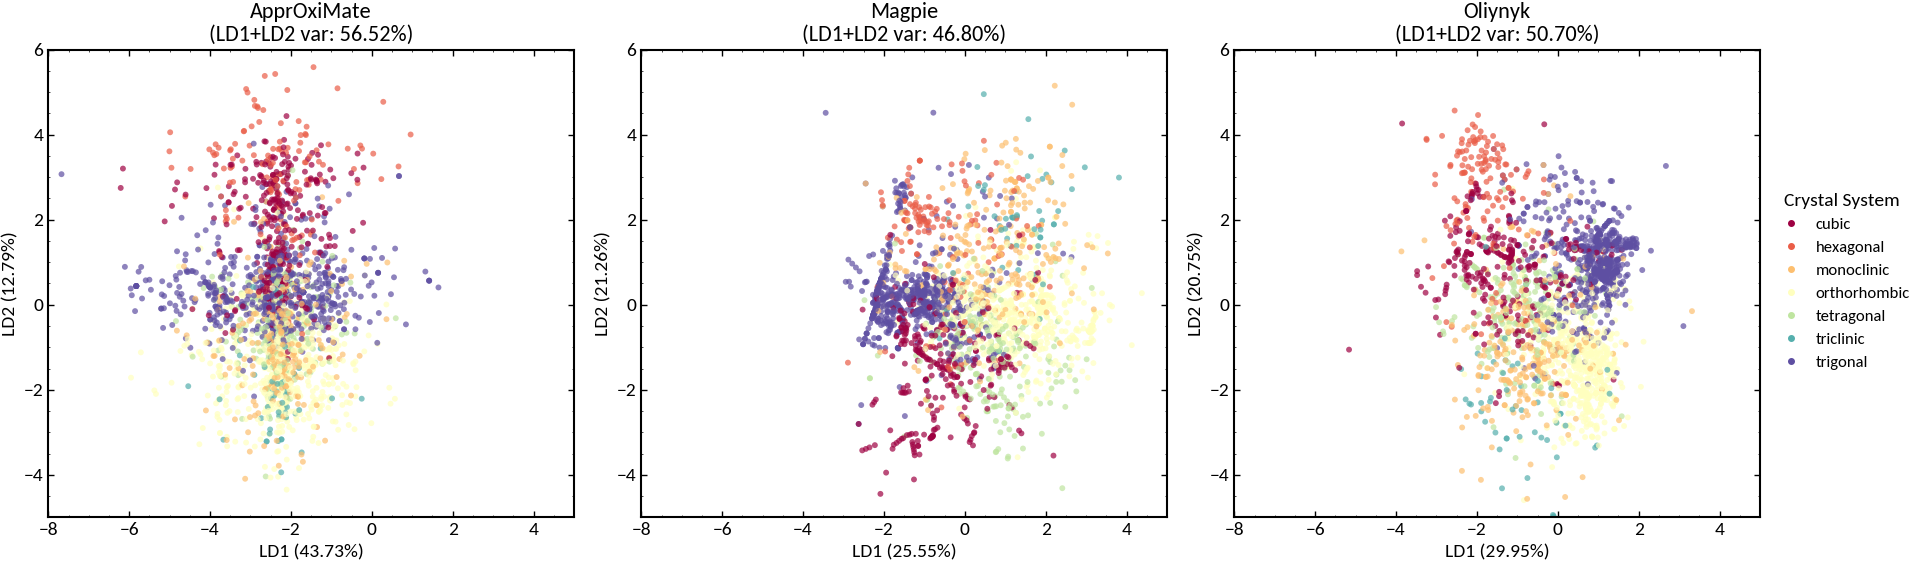

In [12]:
def plot_lda_comparison(feature_sets, label_sets, titles, label_mapping, figsize_per_plot=6):

    n = len(feature_sets)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_plot * n, figsize_per_plot))
    if n == 1:
        axes = [axes]

    classes = sorted(label_mapping.keys())
    cmap = matplotlib.colormaps.get_cmap('Spectral').resampled(len(classes))

    for ax, X, y, title in zip(axes, feature_sets, label_sets, titles):
        lda = LinearDiscriminantAnalysis(n_components=2, solver='svd')
        X_lda = lda.fit_transform(X, y)  # fit on FULL data, outliers included

        ax.scatter(X_lda[:, 0], X_lda[:, 1],
            c=y, cmap=cmap, vmin=min(classes) - 0.5, vmax=max(classes) + 0.5,
            alpha=0.7, s=18, edgecolors='none')

        ax.set_xlim((-8 ,5))
        ax.set_ylim((-5, 6))

        var_explained = lda.explained_variance_ratio_
        ax.set_title(f"{title}\n(LD1+LD2 var: {var_explained[:2].sum():.2%})")
        ax.set_xlabel(f"LD1 ({var_explained[0]:.2%})")
        ax.set_ylabel(f"LD2 ({var_explained[1]:.2%})")

    handles = [
        plt.Line2D([0], [0], marker='o', linestyle='',
                   color=cmap(i), label=label_mapping[c])
        for i, c in enumerate(classes)
    ]
    fig.legend(handles=handles, title="Crystal System",
               loc='center right', bbox_to_anchor=(1.08, 0.5))

    plt.tight_layout()
    plt.show()

plot_lda_comparison(
    feature_sets=[X_full_approx, X_full_magpie, X_full_oliynyk],
    label_sets=[y_full_approx, y_full_magpie, y_full_oliynyk],
    titles=["ApprOxiMate", "Magpie", "Oliynyk"],
    label_mapping=label_mapping_approx)

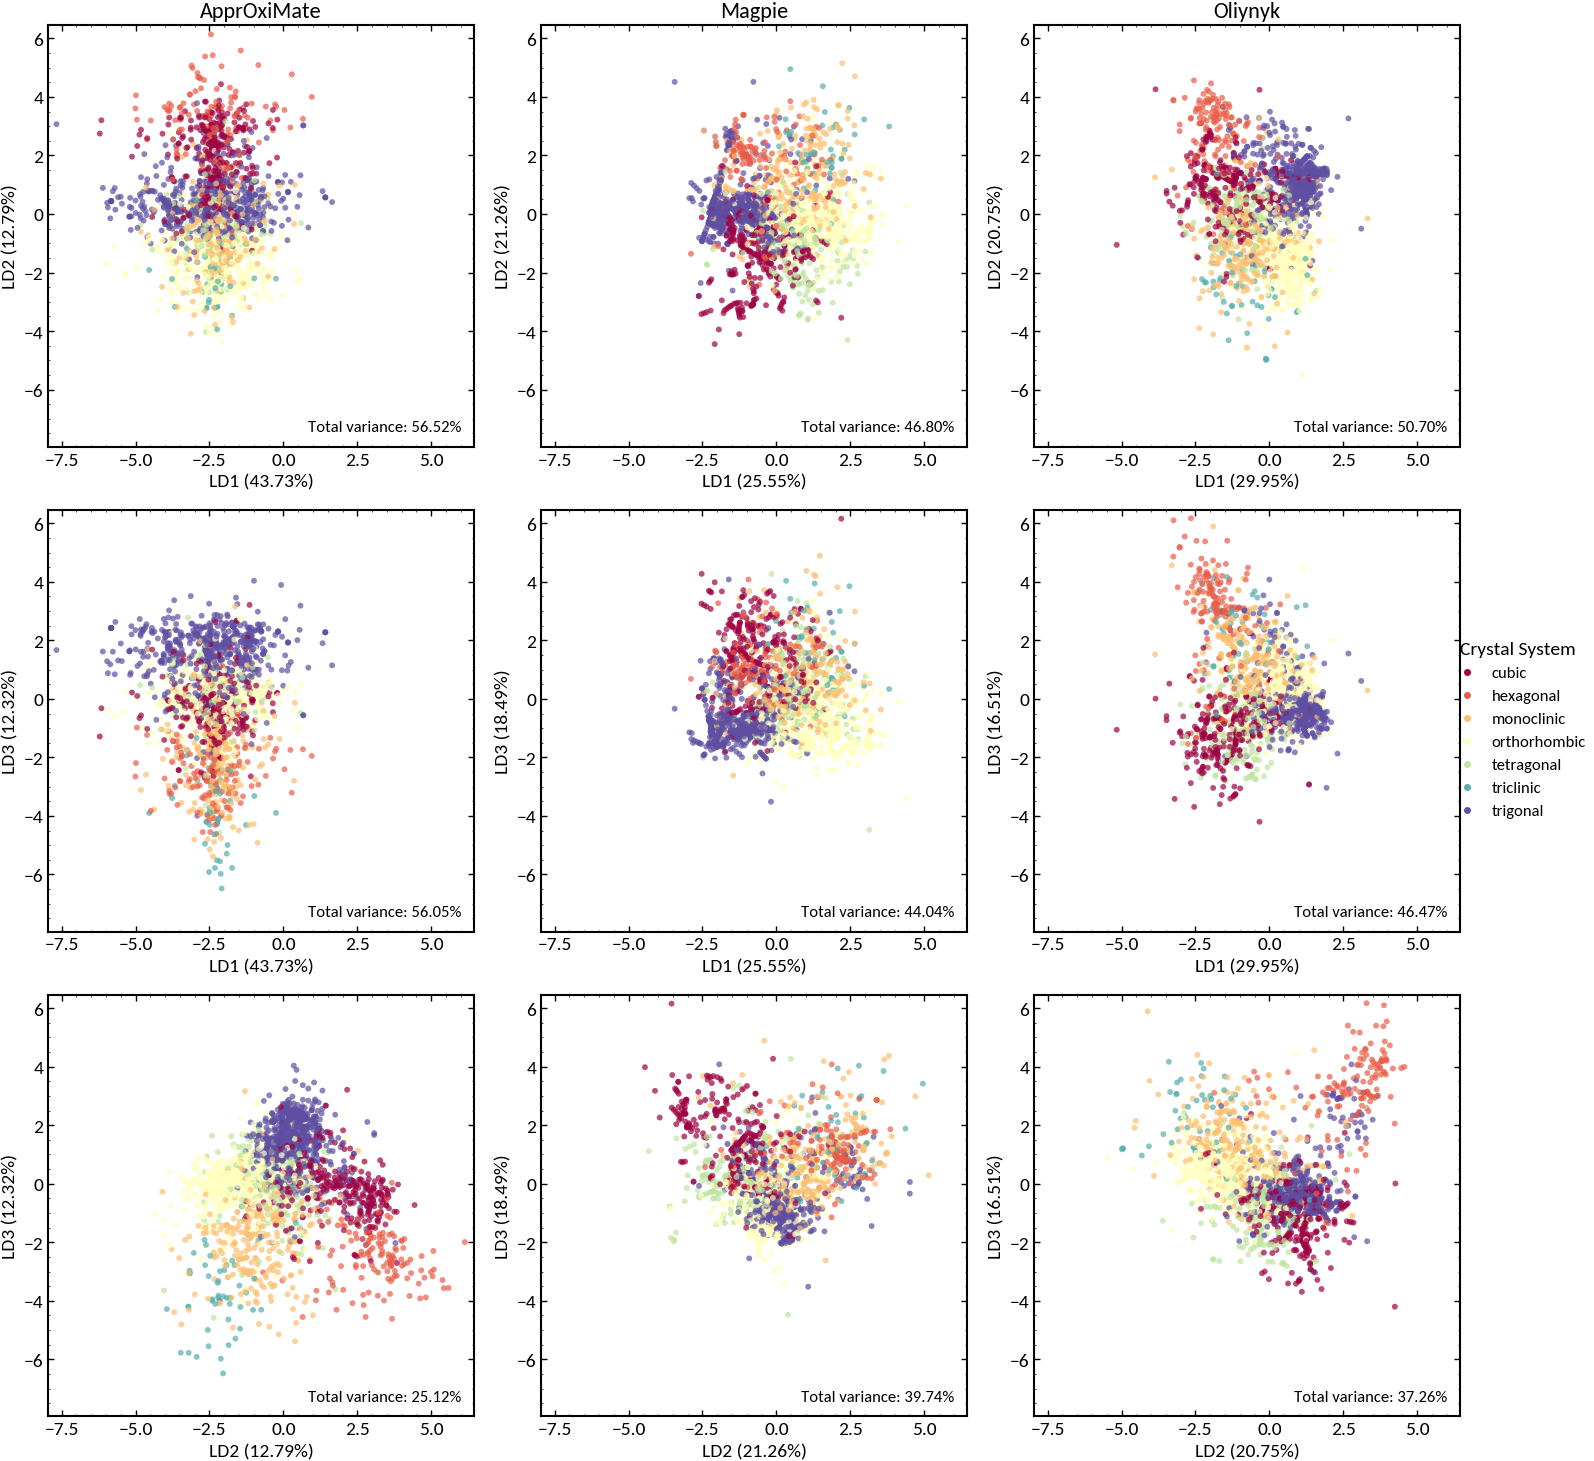

In [13]:
def plot_lda_pairwise(
    feature_sets, label_sets, titles, label_mapping, figsize_per_plot=5):

    n = len(feature_sets)
    pairs = [(0, 1), (0, 2), (1, 2)]

    # 1. Fit LDA for all datasets upfront and store transformed data
    lda_data = []
    global_min = float("inf")
    global_max = float("-inf")

    for X, y in zip(feature_sets, label_sets):
        lda = LinearDiscriminantAnalysis(n_components=3, solver="svd")
        X_lda = lda.fit_transform(X, y)
        var_explained = lda.explained_variance_ratio_

        # Update global bounds with padding factor
        global_min = min(global_min, X_lda.min())
        global_max = max(global_max, X_lda.max())

        lda_data.append((X_lda, var_explained))

    # Add 2% padding around limits for clean visual margins
    padding = (global_max - global_min) * 0.02
    xlims = (global_min - padding, global_max + padding)
    ylims = xlims  # Equal bounds across x and y for direct 1:1 scale comparison

    # 2. Plot grid
    fig, axes = plt.subplots( len(pairs), n, figsize=(figsize_per_plot * n, figsize_per_plot * len(pairs)), squeeze=False,)

    classes = sorted(label_mapping.keys())
    cmap = matplotlib.colormaps.get_cmap("Spectral").resampled(len(classes))

    for col, (X_lda, var_explained) in enumerate(lda_data):
        title = titles[col]
        y = label_sets[col]

        for row, (i, j) in enumerate(pairs):
            ax = axes[row, col]

            ax.scatter(X_lda[:, i], X_lda[:, j], c=y, cmap=cmap,
                vmin=min(classes) - 0.5, vmax=max(classes) + 0.5,
                alpha=0.7,s=18, edgecolors="none")

            # Apply shared global limits
            ax.set_xlim(xlims)
            ax.set_ylim(ylims)

            # Variance details
            pair_variance = var_explained[i] + var_explained[j]

            ax.text(0.97, 0.03, f"Total variance: {pair_variance:.2%}", transform=ax.transAxes, ha="right", va="bottom", fontsize=12)

            ax.set_xlabel(f"LD{i+1} ({var_explained[i]:.2%})")
            ax.set_ylabel(f"LD{j+1} ({var_explained[j]:.2%})")

            if row == 0:
                ax.set_title(title)

    # Class legend
    handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=cmap(i), label=label_mapping[c])
        for i, c in enumerate(classes)]

    fig.legend(handles=handles, title="Crystal System", loc="center right", bbox_to_anchor=(1.08, 0.5))

    plt.tight_layout()
    plt.show()

plot_lda_pairwise(
    feature_sets=[X_full_approx, X_full_magpie, X_full_oliynyk],
    label_sets=[y_full_approx, y_full_magpie, y_full_oliynyk],
    titles=["ApprOxiMate", "Magpie", "Oliynyk"],
    label_mapping=label_mapping_approx)